<a href="https://colab.research.google.com/github/olexvysotina-cell/ML/blob/main/%22%D0%9B%D0%912_1_%D0%92%D0%B8%D1%81%D0%BE%D1%82%D1%96%D0%BD%D0%B0_12_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Прізвище, група

---



# Завдання 1

**Був присутній на парі**

Обробка та аналіз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests


In [3]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"

headers = {
    "User-Agent": "Mozilla/5.0"
}

html = requests.get(url, headers=headers).text

tables = pd.read_html(html)

countries_df = tables[2]

/tmp/ipykernel_1062/2025858785.py:9: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


In [4]:
countries_df.head()

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [5]:
countries_df.shape

(222, 4)

 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [6]:
countries_df = countries_df.rename(columns={
    "Country/Territory": "Country",
    "IMF (2026)[1]": "IMF (2026)",
    "World Bank (2025)[6]": "World Bank (2025)",
    "United Nations (2024)[7]": "United Nations (2024)"
})

In [7]:
countries_df = countries_df[
    ["Country", "IMF (2026)", "World Bank (2025)", "United Nations (2024)"]
    ]

In [8]:
countries_df.columns

Index(['Country', 'IMF (2026)', 'World Bank (2025)', 'United Nations (2024)'], dtype='object')

4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [9]:
countries_df = countries_df.replace("—N/a", np.nan)

In [10]:
countries_df.isna().sum()

,0
Country,0
IMF (2026),24
World Bank (2025),7
United Nations (2024),9


In [11]:
for column in countries_df.columns:
    print(column)
    print(countries_df[column].unique())

Country
['World' 'United States' 'China[n 1]' 'Germany' 'Japan' 'United Kingdom'
 'India' 'France' 'Italy' 'Russia' 'Brazil' 'Canada' 'Australia' 'Mexico'
 'Spain' 'South Korea' 'Turkey' 'Indonesia' 'Netherlands' 'Saudi Arabia'
 'Switzerland' 'Poland' 'Taiwan[n 3]' 'Ireland' 'Belgium' 'Sweden'
 'Israel' 'Argentina' 'Singapore' 'Austria' 'United Arab Emirates'
 'Norway' 'Thailand' 'Colombia' 'Vietnam' 'Malaysia' 'Philippines'
 'Bangladesh' 'Denmark' 'Romania' 'South Africa' 'Hong Kong[n 4]'
 'Czech Republic' 'Egypt' 'Chile' 'Pakistan' 'Peru' 'Portugal' 'Nigeria'
 'Kazakhstan' 'Finland' 'Algeria' 'Greece' 'Iran' 'New Zealand' 'Hungary'
 'Iraq' 'Cuba' 'Ukraine[n 5]' 'Qatar' 'Morocco' 'Uzbekistan' 'Kuwait'
 'Slovakia' 'Angola' 'Bulgaria' 'Kenya' 'Ecuador' 'Dominican Republic'
 'Puerto Rico' 'Guatemala' 'DR Congo' 'Ethiopia' 'Ghana' 'Oman' 'Croatia'
 'Ivory Coast' 'Serbia' 'Venezuela' 'Luxembourg' 'Costa Rica' 'Sri Lanka'
 'Lithuania' 'Belarus' 'Uruguay' 'Panama' 'Tanzania[n 6]' 'Slovenia'


In [12]:
countries_df["IMF (2026)"] = pd.to_numeric(countries_df["IMF (2026)"], errors="coerce")
countries_df["World Bank (2025)"] = pd.to_numeric(countries_df["World Bank (2025)"], errors="coerce")
countries_df["United Nations (2024)"] = pd.to_numeric(countries_df["United Nations (2024)"], errors="coerce")

In [13]:
countries_df = countries_df.fillna(countries_df.mean(numeric_only=True))

In [14]:
countries_df.isna().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


5. Ще раз вивести датасет

In [15]:
countries_df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,1.262953e+08,1.183502e+08,111565144.0
1,United States,3.238392e+07,3.076970e+07,29298000.0
2,China[n 1],2.085159e+07,1.949804e+07,18743802.0
3,Germany,5.452858e+06,5.050923e+06,4659929.0
4,Japan,4.379253e+06,4.435163e+06,4026211.0
...,...,...,...,...
217,Palau,3.770000e+02,3.450000e+02,310.0
218,Marshall Islands,3.420000e+02,3.080000e+02,281.0
219,Nauru,1.960000e+02,1.760000e+02,187.0
220,Montserrat,1.319229e+06,1.255590e+06,81.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [16]:
countries_df.duplicated().sum()

np.int64(0)

7.	Вивести описову статистику датасету describe()

In [17]:
countries_df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.220000e+02,2.220000e+02,2.220000e+02
mean,1.319229e+06,1.255590e+06,1.043818e+06
std,8.838876e+06,8.288461e+06,7.830341e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.932375e+04,2.003400e+04,9.170750e+03
50%,1.039745e+05,9.986350e+04,4.322450e+04
75%,7.726678e+05,1.041520e+06,3.048545e+05
max,1.262953e+08,1.183502e+08,1.115651e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [31]:
countries_df["Difference"] = (
    countries_df["IMF (2026)"] - countries_df["World Bank (2025)"]
).abs()

countries_df[["Country", "Difference"]].sort_values(
    by="Difference",
    ascending=False
).head(5)

,Country,Difference
0,World,7.945165e+06
1,United States,1.614220e+06
2,China[n 1],1.353554e+06
197,Sint Maarten,1.317341e+06
146,Palestine[n 11][n 12],1.302062e+06


Найбільша різниця між показниками у United States, China, Sint Maarten та Palestine

9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [19]:
countries_df[["IMF (2026)", "World Bank (2025)", "United Nations (2024)"]].corr()

,IMF (2026),World Bank (2025),United Nations (2024)
IMF (2026),1.000000,0.999497,0.998998
World Bank (2025),0.999497,1.000000,0.998864
United Nations (2024),0.998998,0.998864,1.000000


In [20]:
countries_df["IMF (2026)"].corr(countries_df["World Bank (2025)"])

np.float64(0.999497330276443)

In [21]:
countries_df["IMF (2026)"].corr(countries_df["United Nations (2024)"])

np.float64(0.9989976232972982)

In [22]:
countries_df["World Bank (2025)"].corr(countries_df["United Nations (2024)"])

np.float64(0.9988643511175539)

Найвищу кореляцію між показниками мають IMF (2026) і World Bank (2025) та IMF (2026) і United Nations (2024)

10.Обчислити середнє значення за стовпцями

In [23]:
countries_df["IMF (2026)"].mean()

np.float64(1319229.2460732986)

In [24]:
countries_df["World Bank (2025)"].mean()

np.float64(1255590.4224598932)

In [25]:
countries_df["United Nations (2024)"].mean()

np.float64(1043818.2159624413)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [26]:
countries = countries_df[countries_df["Country"] != "World"]

countries["std"] = countries[
    ["IMF (2026)", "World Bank (2025)", "United Nations (2024)"]
].std(axis=1)

countries[["Country", "std"]].sort_values(
    by="std",
    ascending=False
).head(1)

/tmp/ipykernel_1062/3315646232.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries["std"] = countries[


,Country,std
1,United States,1.543508e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

В усіх роках найвищий показник має United States і найнижчий показник у Tuvalu

In [27]:
print("IMF (2026):")
print("Найвище:", countries.loc[countries["IMF (2026)"].idxmax(), ["Country", "IMF (2026)"]])
print("Найнижче:", countries.loc[countries["IMF (2026)"].idxmin(), ["Country", "IMF (2026)"]])

print("\nWorld Bank (2025):")
print("Найвище:", countries.loc[countries["World Bank (2025)"].idxmax(), ["Country", "World Bank (2025)"]])
print("Найнижче:", countries.loc[countries["World Bank (2025)"].idxmin(), ["Country", "World Bank (2025)"]])

print("\nUnited Nations (2024):")
print("Найвище:", countries.loc[countries["United Nations (2024)"].idxmax(), ["Country", "United Nations (2024)"]])
print("Найнижче:", countries.loc[countries["United Nations (2024)"].idxmin(), ["Country", "United Nations (2024)"]])

IMF (2026):
Найвище: Country       United States
IMF (2026)       32383920.0
Name: 1, dtype: object
Найнижче: Country       Tuvalu
IMF (2026)      65.0
Name: 221, dtype: object

World Bank (2025):
Найвище: Country              United States
World Bank (2025)       30769700.0
Name: 1, dtype: object
Найнижче: Country              Tuvalu
World Bank (2025)      57.0
Name: 221, dtype: object

United Nations (2024):
Найвище: Country                  United States
United Nations (2024)       29298000.0
Name: 1, dtype: object
Найнижче: Country                  Tuvalu
United Nations (2024)      56.0
Name: 221, dtype: object


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

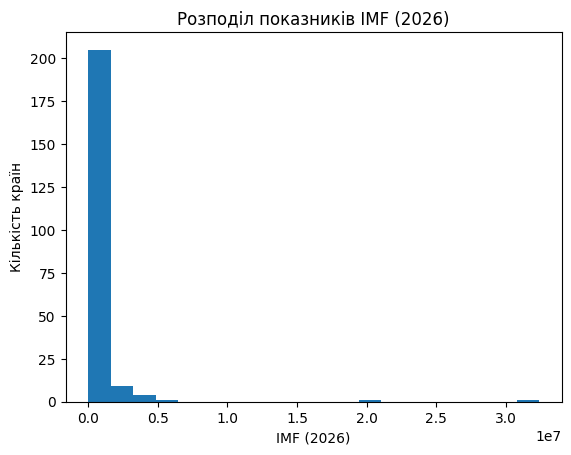

In [28]:
plt.hist(countries["IMF (2026)"], bins=20)
plt.xlabel("IMF (2026)")
plt.ylabel("Кількість країн")
plt.title("Розподіл показників IMF (2026)")
plt.show()

In [33]:
countries[["Country", "IMF (2026)"]].sort_values(
    by="IMF (2026)",
    ascending=False
).head(19)

,Country,IMF (2026)
1,United States,32383920.0
2,China[n 1],20851593.0
3,Germany,5452858.0
4,Japan,4379253.0
5,United Kingdom,4264794.0
6,India,4153191.0
7,France,3596094.0
8,Italy,2738164.0
9,Russia,2656452.0
10,Brazil,2635912.0


За отриманою гістограмою видно, що частина країн виділяється

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [30]:
countries["IMF_share"] = (
    countries["IMF (2026)"] / countries["IMF (2026)"].sum() * 100
)

countries["World_Bank_share"] = (
    countries["World Bank (2025)"] / countries["World Bank (2025)"].sum() * 100
)

countries["Unated_Nations_share"] = (
    countries["United Nations (2024)"] / countries["United Nations (2024)"].sum() * 100
)

countries[[
    "Country",
    "IMF_share",
    "World_Bank_share",
    "Unated_Nations_share"
]]

/tmp/ipykernel_1062/669961774.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries["IMF_share"] = (
/tmp/ipykernel_1062/669961774.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries["World_Bank_share"] = (
/tmp/ipykernel_1062/669961774.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing

,Country,IMF_share,World_Bank_share,Unated_Nations_share
1,United States,19.441212,19.184192,24.381983
2,China[n 1],12.517949,12.156574,15.598712
3,Germany,3.273544,3.149133,3.878023
4,Japan,2.629020,2.765221,3.350639
5,United Kingdom,2.560307,2.495521,3.067414
...,...,...,...,...
217,Palau,0.000226,0.000215,0.000258
218,Marshall Islands,0.000205,0.000192,0.000234
219,Nauru,0.000118,0.000110,0.000156
220,Montserrat,0.791980,0.782831,0.000067


У більшості країн частка 3 2024 до 2026 року зменшилась

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

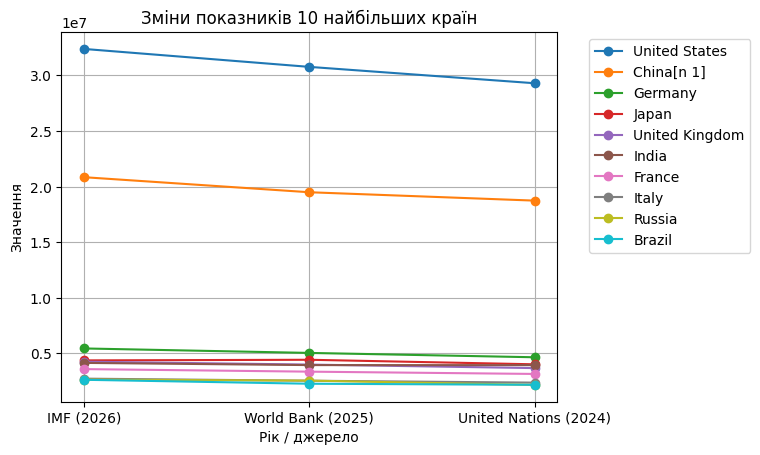

Стабільне зростання:
['United States', 'China[n 1]', 'Germany', 'United Kingdom', 'India', 'France', 'Italy', 'Russia', 'Brazil', 'Canada', 'Spain', 'Turkey', 'Indonesia', 'Netherlands', 'Saudi Arabia', 'Switzerland', 'Poland', 'Ireland', 'Belgium', 'Sweden', 'Israel', 'Argentina', 'Singapore', 'Austria', 'Norway', 'Thailand', 'Colombia', 'Vietnam', 'Malaysia', 'Philippines', 'Bangladesh', 'Denmark', 'Romania', 'South Africa', 'Hong Kong[n 4]', 'Czech Republic', 'Egypt', 'Chile', 'Pakistan', 'Peru', 'Portugal', 'Nigeria', 'Kazakhstan', 'Finland', 'Algeria', 'Greece', 'New Zealand', 'Hungary', 'Cuba', 'Ukraine[n 5]', 'Morocco', 'Uzbekistan', 'Slovakia', 'Angola', 'Bulgaria', 'Kenya', 'Ecuador', 'Dominican Republic', 'Guatemala', 'DR Congo', 'Ghana', 'Oman', 'Croatia', 'Ivory Coast', 'Serbia', 'Luxembourg', 'Costa Rica', 'Sri Lanka', 'Lithuania', 'Belarus', 'Uruguay', 'Panama', 'Tanzania[n 6]', 'Slovenia', 'Myanmar', 'Bolivia', 'Azerbaijan', 'Uganda', 'Cameroon', 'Jordan', 'Tunisia', 'Pa

In [34]:
top10 = countries.nlargest(10, "IMF (2026)")

years = ["IMF (2026)", "World Bank (2025)", "United Nations (2024)"]

for _, row in top10.iterrows():
    plt.plot(
        years,
        row[years],
        marker="o",
        label=row["Country"]
    )

plt.xlabel("Рік / джерело")
plt.ylabel("Значення")
plt.title("Зміни показників 10 найбільших країн")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid()
plt.show()
years = [
    "United Nations (2024)",
    "World Bank (2025)",
    "IMF (2026)"
]

growth = countries[
    (countries[years[0]] < countries[years[1]]) &
    (countries[years[1]] < countries[years[2]])
]

decline = countries[
    (countries[years[0]] > countries[years[1]]) &
    (countries[years[1]] > countries[years[2]])
]

print("Стабільне зростання:")
print(growth["Country"].tolist())

print("\nСтабільний спад:")
print(decline["Country"].tolist())

За графіком видно, що частина країн має стабільне зростання показника протягом трьох років, тобто значення послідовно збільшується від 2024 до 2026 року.

Стабільний спад мають Іран та Ефіопія, де значення послідовно зменшується. Решта країн мають змішану динаміку, коли показник спочатку зростає, а потім зменшується, або навпаки.